![Los Angeles skyline](la_skyline.jpg)

Los Angeles, California 😎. The City of Angels. Tinseltown. The Entertainment Capital of the World! 

Known for its warm weather, palm trees, sprawling coastline, and Hollywood, along with producing some of the most iconic films and songs. However, as with any highly populated city, it isn't always glamorous and there can be a large volume of crime. That's where you can help!

You have been asked to support the Los Angeles Police Department (LAPD) by analyzing crime data to identify patterns in criminal behavior. They plan to use your insights to allocate resources effectively to tackle various crimes in different areas.

## The Data

They have provided you with a single dataset to use. A summary and preview are provided below.

It is a modified version of the original data, which is publicly available from Los Angeles Open Data.

# crimes.csv

| Column     | Description              |
|------------|--------------------------|
| `'DR_NO'` | Division of Records Number: Official file number made up of a 2-digit year, area ID, and 5 digits. |
| `'Date Rptd'` | Date reported - MM/DD/YYYY. |
| `'DATE OCC'` | Date of occurrence - MM/DD/YYYY. |
| `'TIME OCC'` | In 24-hour military time. |
| `'AREA NAME'` | The 21 Geographic Areas or Patrol Divisions are also given a name designation that references a landmark or the surrounding community that it is responsible for. For example, the 77th Street Division is located at the intersection of South Broadway and 77th Street, serving neighborhoods in South Los Angeles. |
| `'Crm Cd Desc'` | Indicates the crime committed. |
| `'Vict Age'` | Victim's age in years. |
| `'Vict Sex'` | Victim's sex: `F`: Female, `M`: Male, `X`: Unknown. |
| `'Vict Descent'` | Victim's descent:<ul><li>`A` - Other Asian</li><li>`B` - Black</li><li>`C` - Chinese</li><li>`D` - Cambodian</li><li>`F` - Filipino</li><li>`G` - Guamanian</li><li>`H` - Hispanic/Latin/Mexican</li><li>`I` - American Indian/Alaskan Native</li><li>`J` - Japanese</li><li>`K` - Korean</li><li>`L` - Laotian</li><li>`O` - Other</li><li>`P` - Pacific Islander</li><li>`S` - Samoan</li><li>`U` - Hawaiian</li><li>`V` - Vietnamese</li><li>`W` - White</li><li>`X` - Unknown</li><li>`Z` - Asian Indian</li> |
| `'Weapon Desc'` | Description of the weapon used (if applicable). |
| `'Status Desc'` | Crime status. |
| `'LOCATION'` | Street address of the crime. |

In [2]:
# Importing required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
crimes = pd.read_csv("crimes.csv", parse_dates=["Date Rptd", "DATE OCC"], dtype={"TIME OCC": str})
crimes.head()

,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA NAME,Crm Cd Desc,Vict Age,Vict Sex,Vict Descent,Weapon Desc,Status Desc,LOCATION
0,221412410,2022-06-15,2020-11-12,1700,Pacific,THEFT FROM MOTOR VEHICLE - PETTY ($950 & UNDER),0,NaN,NaN,NaN,Invest Cont,13600 MARINA POINT DR
1,220314085,2022-07-22,2020-05-12,1110,Southwest,THEFT OF IDENTITY,27,F,B,NaN,Invest Cont,2500 S SYCAMORE AV
2,222013040,2022-08-06,2020-06-04,1620,Olympic,THEFT OF IDENTITY,60,M,H,NaN,Invest Cont,3300 SAN MARINO ST
3,220614831,2022-08-18,2020-08-17,1200,Hollywood,THEFT OF IDENTITY,28,M,H,NaN,Invest Cont,1900 TRANSIENT
4,231207725,2023-02-27,2020-01-27,0635,77th Street,THEFT OF IDENTITY,37,M,H,NaN,Invest Cont,6200 4TH AV


In [3]:
crimes.tail()

,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA NAME,Crm Cd Desc,Vict Age,Vict Sex,Vict Descent,Weapon Desc,Status Desc,LOCATION
247983,231510379,2023-05-29,2023-05-25,1100,N Hollywood,"BUNCO, GRAND THEFT",25,M,W,NaN,Invest Cont,5300 DENNY AV
247984,231604807,2023-01-27,2023-01-26,1800,Foothill,"VANDALISM - FELONY ($400 & OVER, ALL CHURCH VA...",23,M,H,NaN,Invest Cont,12500 BRANFORD ST
247985,231606525,2023-03-22,2023-03-22,1000,Foothill,"ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT",25,F,H,"STRONG-ARM (HANDS, FIST, FEET OR BODILY FORCE)",Invest Cont,12800 FILMORE ST
247986,231210064,2023-04-12,2023-04-12,1630,77th Street,"ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT",29,M,B,UNKNOWN WEAPON/OTHER WEAPON,Invest Cont,6100 S VERMONT AV
247987,230906458,2023-03-05,2023-03-05,0900,Van Nuys,VANDALISM - MISDEAMEANOR ($399 OR UNDER),53,F,H,NaN,Invest Cont,14500 HARTLAND ST


In [4]:
crimes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 247988 entries, 0 to 247987
Data columns (total 12 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   DR_NO         247988 non-null  int64         
 1   Date Rptd     247988 non-null  datetime64[ns]
 2   DATE OCC      247988 non-null  datetime64[ns]
 3   TIME OCC      247988 non-null  object        
 4   AREA NAME     247988 non-null  object        
 5   Crm Cd Desc   247988 non-null  object        
 6   Vict Age      247988 non-null  int64         
 7   Vict Sex      215740 non-null  object        
 8   Vict Descent  215739 non-null  object        
 9   Weapon Desc   80087 non-null   object        
 10  Status Desc   247988 non-null  object        
 11  LOCATION      247988 non-null  object        
dtypes: datetime64[ns](2), int64(2), object(8)
memory usage: 22.7+ MB


In [5]:
crimes.shape

(247988, 12)

In [6]:
# Above there are 247988 records and 12 attributes and in which 2 attributes are numeric, 2 are date time and 8 are object data types.
# The attributes Vict Sex, Vict Descent, Weapon Desc have null values.   

In [7]:
# Checking for Nulls count

In [8]:
crimes.isnull().sum()

DR_NO                0
Date Rptd            0
DATE OCC             0
TIME OCC             0
AREA NAME            0
Crm Cd Desc          0
Vict Age             0
Vict Sex         32248
Vict Descent     32249
Weapon Desc     167901
Status Desc          0
LOCATION             0
dtype: int64

In [9]:
# Summary statistics of numeric columns

In [10]:
crimes.describe()

,DR_NO,Vict Age
count,2.479880e+05,247988.000000
mean,2.256571e+08,29.954764
std,5.042345e+06,21.901016
min,2.203000e+03,-2.000000
25%,2.210130e+08,0.000000
50%,2.220131e+08,31.000000
75%,2.310058e+08,45.000000
max,2.399165e+08,99.000000


In [11]:
# DR_NO cannot be infered from above as it doesn't make sense.

In [12]:
# The ages of the victims have high range and also has negative age -2, which doesn't make sesne(as age cannot be negative)

In [13]:
# Value Counts for Age

In [14]:
crimes["Vict Age"].value_counts()

 0     62240
 30     5715
 35     5697
 32     5481
 31     5472
       ...  
 95       25
 94       23
 97       22
 98       17
-2         7
Name: Vict Age, Length: 101, dtype: int64

In [15]:
# The values of age i.e 0 and -2 doesnt make sense as age is not negative or could not be zero, it might be the data might not be available or human error.
# Other than that, the Victims are 30 year old individuals and followed by 35 years are the highest with frequency.

In [16]:
# Value Counts for object data type columns

In [17]:
# TIME OCC is 24 hour military time. The day in military time begins at midnight with 0000, pronounced "zero hundred hours" or simply "zero hundred." You then add one hundred for each hour, so 1 a.m. is 0100 (zero one hundred) hours, 2 a.m. is 0200 (zero two hundred) hours and so forth.

In [18]:
crimes_cat=crimes.select_dtypes(include="object")

In [19]:
# The highest reported crimes occured during 1200 i.e 12PM in the noon and least occured during 0531 5:31 AM.

In [20]:
crimes_cat["AREA NAME"].value_counts()

Central        18732
77th Street    15408
Southwest      14194
Pacific        13866
Olympic        12792
Newton         12790
Hollywood      12761
Southeast      12600
Wilshire       12080
N Hollywood    11728
Rampart        11725
West LA        11169
West Valley    10766
Northeast      10686
Van Nuys       10640
Devonshire     10184
Topanga         9968
Harbor          9701
Mission         9175
Hollenbeck      9063
Foothill        7960
Name: AREA NAME, dtype: int64

In [21]:
# The frequency of the area names in the records given above where the Central is the hihgest reported and Foothill is the least reported.

In [22]:
crimes_cat["Crm Cd Desc"].value_counts()

VEHICLE - STOLEN                            25797
THEFT OF IDENTITY                           23017
BATTERY - SIMPLE ASSAULT                    19970
BURGLARY                                    15163
BURGLARY FROM VEHICLE                       14280
                                            ...  
BIGAMY                                          1
INCITING A RIOT                                 1
GRAND THEFT / INSURANCE FRAUD                   1
FIREARMS RESTRAINING ORDER (FIREARMS RO)        1
DRUGS, TO A MINOR                               1
Name: Crm Cd Desc, Length: 110, dtype: int64

In [23]:
# From above the hihgest crimes reported are Vehicle stolen ,continued by Identity theft and several crimes as least reported such as bigamy, inciting a riot and ...

In [24]:
crimes_cat["Vict Sex"].value_counts()

M    101028
F     90804
X     23877
H        30
-         1
Name: Vict Sex, dtype: int64

In [25]:
# There are 5 categories of sex, 4 with name of the sex and another with none.

In [26]:
crimes_cat["Vict Descent"].value_counts()

H    75350
W    48593
B    35307
X    26059
O    19516
A     5610
K     1398
F     1232
C     1210
J      434
V      329
I      322
Z      145
P       83
U       77
D       21
L       20
S       17
G       14
-        2
Name: Vict Descent, dtype: int64

In [27]:
# The most victims are from Hispaniac or Mexican Decent

In [28]:
crimes_cat["Weapon Desc"].value_counts()

STRONG-ARM (HANDS, FIST, FEET OR BODILY FORCE)    42115
UNKNOWN WEAPON/OTHER WEAPON                        8571
VERBAL THREAT                                      6366
HAND GUN                                           5116
SEMI-AUTOMATIC PISTOL                              1782
                                                  ...  
ANTIQUE FIREARM                                       3
RELIC FIREARM                                         1
M-14 SEMIAUTOMATIC ASSAULT RIFLE                      1
BOWIE KNIFE                                           1
MAC-10 SEMIAUTOMATIC ASSAULT WEAPON                   1
Name: Weapon Desc, Length: 74, dtype: int64

In [29]:
# The toal 80087 incident where weapons got involved and out of which STRONG-ARM (HANDS, FIST, FEET OR BODILY FORCE) were recorded highest and Bowie Knife,.. are reported the least.

In [30]:
crimes_cat["Status Desc"].value_counts()

Invest Cont     210171
Adult Other      19192
Adult Arrest     17547
Juv Arrest         660
Juv Other          416
UNK                  2
Name: Status Desc, dtype: int64

In [31]:
# The highest category of Crime Status is that are being investigted currently.

In [32]:
crimes_cat["LOCATION"].value_counts()

10200    SANTA MONICA                 BL    647
100    THE GROVE                    DR      512
400 S  LA BREA                      AV      493
700 S  FIGUEROA                     ST      479
600 S  BROADWAY                             448
                                           ... 
IBANEZ                                        1
13700    LEADWELL                     ST      1
E  EDGEWARE                     RD            1
11100    SARDIS                       AV      1
1000    MILWAUKEE                    AV       1
Name: LOCATION, Length: 43667, dtype: int64

In [33]:
# The location Santa Monica is the highest location with crime incidents.

In [34]:
# DATA VISUALISATION

In [35]:
# univariate plots

In [36]:
crimes["TIME OCC"].value_counts()

1200    8333
1800    6183
1700    5824
2000    5606
1900    5250
        ... 
0756       5
2254       5
2259       5
0542       5
0531       3
Name: TIME OCC, Length: 1439, dtype: int64

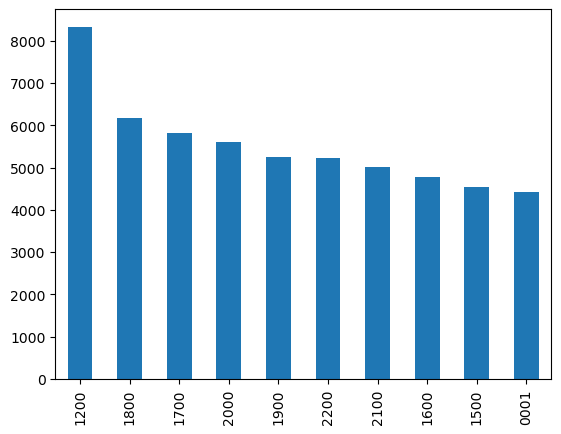

In [37]:
a=crimes["TIME OCC"].value_counts().nlargest(10).plot(kind='bar')
plt.show() 

In [38]:
# These are the top 10 hours at which the most crimes reported took place
# 1200(12PM in Noon) is the time or hour with high cirmes reported.
peak_crime_hour=1200

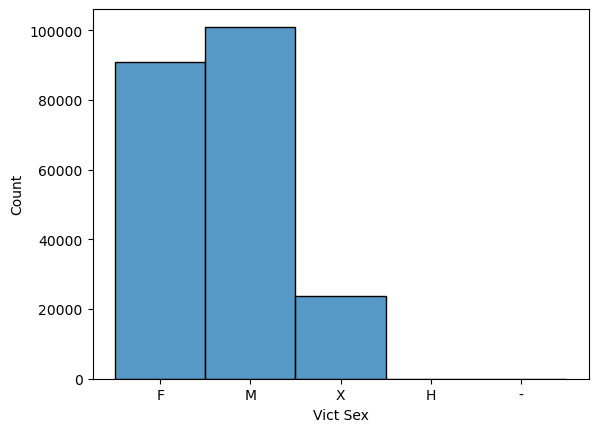

In [39]:
sns.histplot(data=crimes,x=crimes["Vict Sex"])
plt.show()

In [40]:
# On Males the highest no.of crimes have been commited followed by Females.

In [41]:
age_bins = [0, 17, 25, 34, 44, 54, 64, np.inf]
age_labels = ["<18", "18-25", "26-34", "35-44", "45-54", "55-64", "65+"]

In [42]:
crimes["Age Bracket"] = pd.cut(crimes["Vict Age"],
                               bins=age_bins,
                               labels=age_labels)

In [43]:
victim_ages = crimes["Age Bracket"].value_counts()
print(victim_ages)

26-34    47470
35-44    42157
45-54    28353
18-25    28291
55-64    20169
65+      14747
<18       4528
Name: Age Bracket, dtype: int64


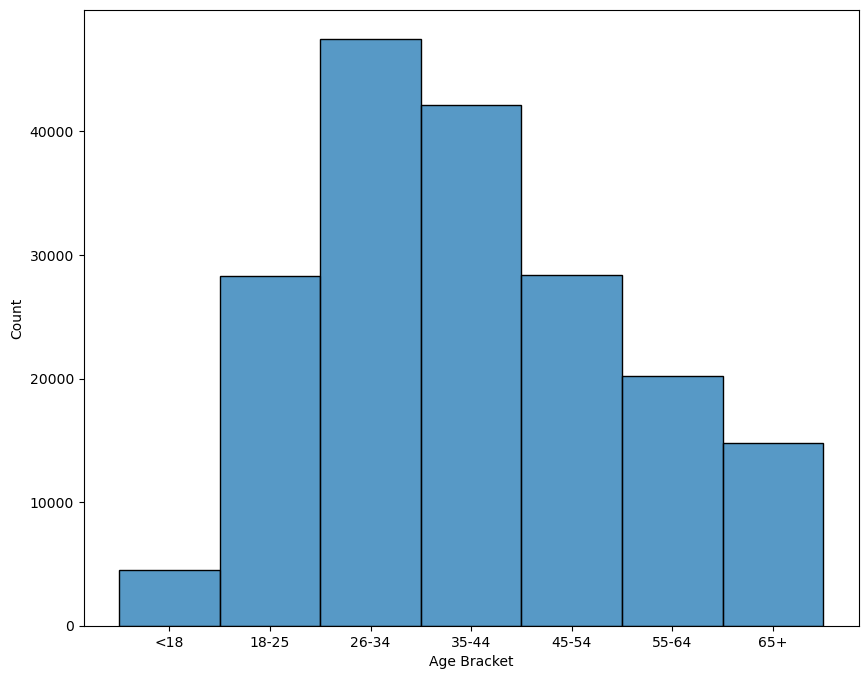

In [44]:
plt.figure(figsize=(10,8))
sns.histplot(data=crimes,x=crimes["Age Bracket"])
plt.show()

In [45]:
# The Victims from the age group 26-34 are the ones with high crimes reported.

In [46]:
# Delay between the crime occured and reported

In [47]:
crimes.columns

Index(['DR_NO', 'Date Rptd', 'DATE OCC', 'TIME OCC', 'AREA NAME',
       'Crm Cd Desc', 'Vict Age', 'Vict Sex', 'Vict Descent', 'Weapon Desc',
       'Status Desc', 'LOCATION', 'Age Bracket'],
      dtype='object')

In [48]:
crimes_dealy=crimes["Date Rptd"]-crimes["DATE OCC"]

In [49]:
crimes_dealy.head()

0    580 days
1    801 days
2    793 days
3    731 days
4   1127 days
dtype: timedelta64[ns]

In [50]:
crimes_dealy.value_counts()

0 days       118809
1 days        53833
2 days        16112
3 days         9369
4 days         6207
              ...  
989 days          1
878 days          1
1023 days         1
775 days          1
446 days          1
Length: 1054, dtype: int64

In [51]:
# most of the crimes are reported when they have occured and most of them lie in the 0-4 days bucket.

In [52]:
crimes["Crm Cd Desc"].value_counts()

VEHICLE - STOLEN                            25797
THEFT OF IDENTITY                           23017
BATTERY - SIMPLE ASSAULT                    19970
BURGLARY                                    15163
BURGLARY FROM VEHICLE                       14280
                                            ...  
BIGAMY                                          1
INCITING A RIOT                                 1
GRAND THEFT / INSURANCE FRAUD                   1
FIREARMS RESTRAINING ORDER (FIREARMS RO)        1
DRUGS, TO A MINOR                               1
Name: Crm Cd Desc, Length: 110, dtype: int64

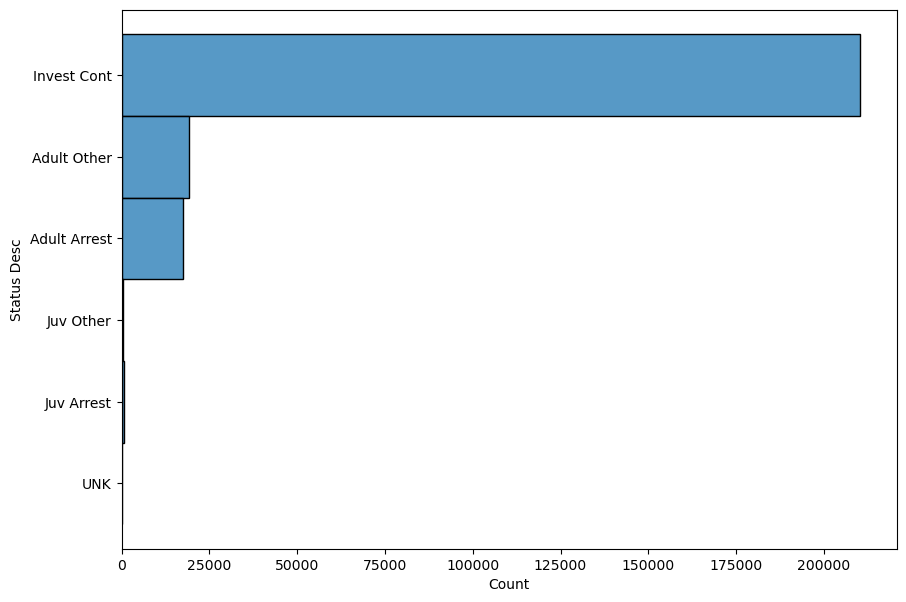

In [53]:
plt.figure(figsize=(10,7))
sns.histplot(data=crimes,y=crimes["Status Desc"])
plt.show()

In [54]:
# most of the crimes reported are under investigation.

<Axes: xlabel='Count', ylabel='AREA NAME'>

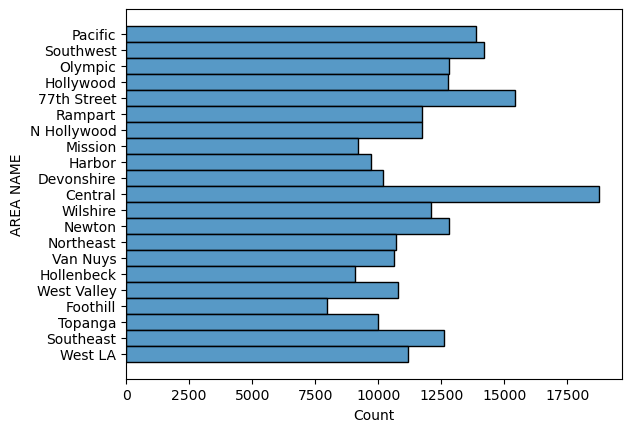

In [55]:
sns.histplot(y=crimes["AREA NAME"])

In [56]:
# The are Central reported highest crimes

In [57]:
crimes["TIME OCC"]=crimes["TIME OCC"].astype("int")

In [58]:
condition = (crimes["TIME OCC"] > 2200) | (crimes["TIME OCC"] < 359)
new_crimes=crimes[condition]

In [59]:
new_crimes["AREA NAME"].value_counts().nlargest(1)

Central    3722
Name: AREA NAME, dtype: int64

In [60]:
peak_night_crime_location="Central"

In [61]:
# The largest frequency of night crimes are reported from Central Area.

In [62]:
peak_crime_hour=12

In [63]:
victim_ages=pd.Series(victim_ages)
type(victim_ages)

pandas.core.series.Series

## Insights Drawn:

In [64]:
# peak_crime hour is?
print("peak_crime hour is "+str(peak_crime_hour))

peak_crime hour is 12


In [67]:
# The area with most no.of cases reported
print(" The area with most no.of cases reported is "+str(peak_night_crime_location)+"area")

 The area with most no.of cases reported is Centralarea


In [68]:
# The age-group that is?
print("The age-group that has most no.of cases are:",victim_ages)

The age-group that has most no.of cases are: 26-34    47470
35-44    42157
45-54    28353
18-25    28291
55-64    20169
65+      14747
<18       4528
Name: Age Bracket, dtype: int64
